In [1]:
!pip install yfinance
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from qpsolvers import solve_qp

/home/hale3105/anaconda3/envs/gsoc/lib/python3.11/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


#### 1. Data fetching & Portfolio generation

In [2]:
# Tickers of Apple, Coca-Cola and JPMorgan Chase
tickers = ["AAPL","KO","JPM"]

start_date = "2024-01-01"
end_date = "2026-02-17"

# Download stock prices from Yahoo Finance
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"] # keep only closing price

print("Number of trading days:", len(data))
data.head()

[*********************100%***********************]  3 of 3 completed

Number of trading days: 532


Ticker,AAPL,JPM,KO
Date,,,
2024-01-02,183.731293,163.843582,55.998600
2024-01-03,182.355621,163.129471,56.129654
2024-01-04,180.039658,164.212006,55.942432
2024-01-05,179.317169,165.035904,55.858177
2024-01-08,183.652145,164.796432,56.270073


In [3]:
# Calculate daily returns from price data
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,JPM,KO
Date,,,
2024-01-03,-0.007487,-0.004358,0.002340
2024-01-04,-0.012700,0.006636,-0.003336
2024-01-05,-0.004013,0.005017,-0.001506
2024-01-08,0.024175,-0.001451,0.007374
2024-01-09,-0.002263,-0.007906,-0.001830


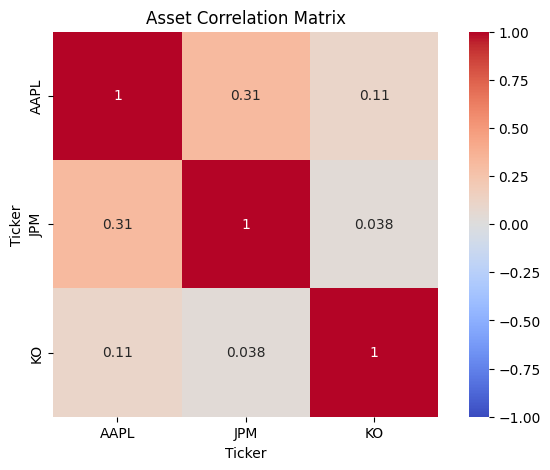

In [4]:
# Plot the correlation matrix of the asset returns
plt.figure(figsize=(8,5))
sns.heatmap(returns.corr(),annot=True,cmap="coolwarm",vmin=-1,vmax=1,square=True)
plt.title("Asset Correlation Matrix")
plt.show()

In [5]:
# Calculate the mean return for each asset
mean_returns = returns.mean().values * 252 # Annualize the mean returns
mean_returns

array([0.195435  , 0.3210208 , 0.17025084])

One million portfolios are generated, subject to two constraints: 

$$
\sum_{i=1}^{N} w_i = 1 \quad \text{(fully invested portfolio)}
$$

$$
w_i \ge 0 \quad \text{(no short-selling)}
$$

In [6]:
# Number of portfolios 
n_portfolios = 1000000

# Define assets 
n_assets = len(tickers)
asset_names = ['Apple', 'Coca-Cola', 'JPMorgan Chase']

# Generate random weights for each portfolio
np.random.seed(42) # for reproducibility
weights = np.random.exponential(scale=1.0, size=(n_portfolios, n_assets))

# Normalize the weights (so that the sum of each portfolio equals 1)
weights = weights / weights.sum(axis=1, keepdims=True)

# Create a DataFrame 
portfolios = pd.DataFrame(weights, columns=asset_names)
portfolios

,Apple,Coca-Cola,JPMorgan Chase
0,0.097843,0.627614,0.274543
1,0.729092,0.135465,0.135443
2,0.020012,0.672618,0.307370
3,0.258905,0.004374,0.736721
4,0.802602,0.107237,0.090161
...,...,...,...
999995,0.141782,0.184437,0.673781
999996,0.190535,0.353373,0.456093
999997,0.146691,0.635392,0.217917
999998,0.155469,0.523646,0.320885


#### 2. Expected portfolio return

The expected return of a portfolio can be calculated as:

$$
R = \sum_{i=1}^{N} w_i \cdot R_i
$$

It can also be computed (as used in the code) using matrix notation:

$$
R = \bm{w}^\top \boldsymbol{\mu}
$$

Where:  
- $R$ = Expected portfolio return  
- $\bm{w}$ = Vector of portfolio weights ($[w_1, w_2, ..., w_n]$)  
- $\boldsymbol{\mu}$ = Vector of expected returns ($[\mu_1, \mu_2, ..., \mu_n]$)  
- $n$ = Number of assets

In [7]:
# Calculate the expected return for each portfolio
portfolios["return"] = weights @ mean_returns
portfolios.head()

,Apple,Coca-Cola,JPMorgan Chase,return
0,0.097843,0.627614,0.274543,0.267340
1,0.729092,0.135465,0.135443,0.209037
2,0.020012,0.672618,0.307370,0.272165
3,0.258905,0.004374,0.736721,0.177431
4,0.802602,0.107237,0.090161,0.206632


#### 3. Portfolio risk (Volatility)

The risk of a portfolio is measured using the **variance** of its returns.  
Portfolio variance is calculated as:

$$
\mathrm{Var}(R) = \bm{w} \mathbf{\Sigma} \bm{w}^\top
$$

Where:  
- $\mathrm{Var}(R)$ = Portfolio variance  
- $\bm{w}$ = Vector of portfolio weights ($[w_1, w_2, ..., w_n]$)  
- $\mathbf{\Sigma}$ = Covariance matrix of asset returns  

The **portfolio risk (volatility)** is the square root of the variance:

$$
\sigma_p = \sqrt{\mathrm{Var}(R)} = \sqrt{\bm{w} \mathbf{\Sigma} \bm{w}^\top}
$$

Where:  
- $\sigma_p$ = Portfolio risk (standard deviation)

This formulation shows how asset weights and their covariance determine the overall portfolio risk.

In [8]:
# Calculate the covariance matrix of the returns
cov_matrix = returns.cov().values * 252 # Annualize the covariance matrix

cov_matrix

array([[0.07762608, 0.021289  , 0.00462945],
       [0.021289  , 0.05972167, 0.00143098],
       [0.00462945, 0.00143098, 0.02424225]])

In [9]:
# Calculate the variance of each portfolio
portfolios["variance"] = np.einsum('ij,jk,ik->i',weights, cov_matrix, weights)

# Calculate the risk of each portfolio
portfolios["risk"] = np.sqrt(portfolios["variance"])

portfolios.head()

,Apple,Coca-Cola,JPMorgan Chase,return,variance,risk
0,0.097843,0.627614,0.274543,0.267340,0.029451,0.171613
1,0.729092,0.135465,0.135443,0.209037,0.047977,0.219036
2,0.020012,0.672618,0.307370,0.272165,0.030562,0.174820
3,0.258905,0.004374,0.736721,0.177431,0.020186,0.142076
4,0.802602,0.107237,0.090161,0.206632,0.055251,0.235054


#### 4. Sharpe ratio

The **Sharpe ratio** measures the risk-adjusted return of a portfolio:

$$
\text{Sharpe}_p = \frac{R_p - r_f}{\sigma_p}
$$

Where:  
- $\text{Sharpe}_p$ = Sharpe ratio of the portfolio  
- $R_p$ = Expected portfolio return  
- $r_f$ = Risk-free rate (e.g., 0%)  
- $\sigma_p$ = Portfolio risk (standard deviation)  

In [10]:
# Define the risk-free rate (here 0%)
risk_free_rate = 0.0

# Calculate the Sharpe Ratio for each portfolio
portfolios["sharpe_ratio"] = (portfolios["return"] - risk_free_rate) / portfolios["risk"]

portfolios.head()

,Apple,Coca-Cola,JPMorgan Chase,return,variance,risk,sharpe_ratio
0,0.097843,0.627614,0.274543,0.267340,0.029451,0.171613,1.557806
1,0.729092,0.135465,0.135443,0.209037,0.047977,0.219036,0.954347
2,0.020012,0.672618,0.307370,0.272165,0.030562,0.174820,1.556829
3,0.258905,0.004374,0.736721,0.177431,0.020186,0.142076,1.248838
4,0.802602,0.107237,0.090161,0.206632,0.055251,0.235054,0.879081


#### 5. Monte Carlo Simulation 

We plot a scatter plot where:
- Each point represents **one simulated portfolio**
- The **x-axis** shows the portfolio **risk (volatility)**
- The **y-axis** shows the **expected return**
- The **color** represents the **Sharpe Ratio**

Portfolios with higher Sharpe ratios are generally better because they provide **more return for each unit of risk**.


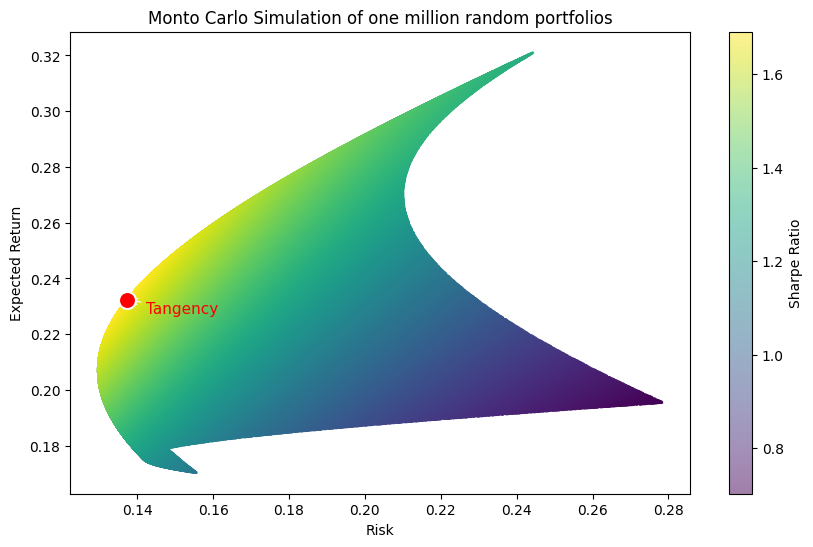

In [11]:
# Tangency Portfolio 
tangency   = portfolios.loc[portfolios["sharpe_ratio"].idxmax()]
tan_risk   = tangency["risk"]
tan_return = tangency["return"]

# Plot a scatter plot of all portfolios
plt.figure(figsize=(10,6))
plt.scatter(portfolios["risk"], portfolios["return"], c=portfolios["sharpe_ratio"], cmap="viridis", s=1, alpha=0.5)
plt.colorbar(label="Sharpe Ratio")

# Plot the tangency portfolio
plt.scatter(tan_risk, tan_return, color="red", s=150, zorder=5, edgecolors="white", linewidths=1.5)
plt.annotate("Tangency",xy=(tan_risk, tan_return), xytext=(tan_risk + 0.005, tan_return - 0.005), color="red", fontsize=11, arrowprops=dict(arrowstyle="->", color="white", lw=0.8))

plt.xlabel("Risk")
plt.ylabel("Expected Return")
plt.title("Monto Carlo Simulation of one million random portfolios")
plt.show()

In [12]:
# Sort the portfolios by sharpe ratio in descending order to show the portfolios with the highest risk-adjusted return first
portfolios.sort_values(by="sharpe_ratio", ascending=False).head()

,Apple,Coca-Cola,JPMorgan Chase,return,variance,risk,sharpe_ratio
699878,0.062716,0.401341,0.535944,0.232340,0.018887,0.137429,1.690623
191488,0.063134,0.401378,0.535488,0.232357,0.018889,0.137438,1.690623
83004,0.061818,0.402856,0.535326,0.232546,0.018920,0.137551,1.690621
277298,0.063164,0.402518,0.534318,0.232529,0.018917,0.137541,1.690620
45604,0.062016,0.403246,0.534738,0.232610,0.018931,0.137589,1.690620


#### 6. Risk contribution

 

The **risk contribution** of each asset to the total portfolio risk is:

$$
RC_i = \frac{ w_i (\mathbf{\Sigma} \bm{w})_i }{\sigma_p}
$$

Where:  
- $RC_i$ = Risk contribution of asset $i$  
- $w_i$ = Weight of asset $i$  
- $(\mathbf{\Sigma} \bm{w})_i$ = Contribution of asset $i$ to portfolio variance  
- $\sigma_p$ = Portfolio risk 

In [13]:
# Calculate the contribution of each asset to the total portfolio risk
risk_contrib = (weights * (weights @ cov_matrix)) / portfolios["risk"].values[:, np.newaxis]

# Adding risk contribution to the DataFrame
portfolios[["RC_" + a for a in asset_names]] = risk_contrib

portfolios.head()

,Apple,Coca-Cola,JPMorgan Chase,return,variance,risk,sharpe_ratio,RC_Apple,RC_Coca-Cola,RC_JPMorgan Chase
0,0.097843,0.627614,0.274543,0.267340,0.029451,0.171613,1.557806,0.012673,0.146132,0.012809
1,0.729092,0.135465,0.135443,0.209037,0.047977,0.219036,0.954347,0.200076,0.014723,0.004237
2,0.020012,0.672618,0.307370,0.272165,0.030562,0.174820,1.556829,0.001980,0.157884,0.014956
3,0.258905,0.004374,0.736721,0.177431,0.020186,0.142076,1.248838,0.043009,0.000210,0.098857
4,0.802602,0.107237,0.090161,0.206632,0.055251,0.235054,0.879081,0.221956,0.010776,0.002322


#### 7. Risk parity

A **risk parity portfolio** aims to allocate weights so that each asset contributes equally to total portfolio risk.

To achieve **risk parity**, we define an objective function that **minimizes the differences in risk contributions**:

$$
\text{Objective} = \sum_{i=1}^{N} (RC_i - \overline{RC})^2
$$

Where:  
- $RC_i$ = Risk contribution of asset $i$  
- $\overline{RC}$ = Average risk contribution across all assets  

Minimizing this ensures all assets contribute equally to portfolio risk  

In [14]:
# Define the Risk Parity objective function
def risk_parity_objective(w, cov):

    print('weight:', w)
    print('cov:', cov)
    
    # Calculate portfolio standard deviation (risk)
    sigma_p = np.sqrt(w @ cov @ w)
    
    # Calculate risk contribution of each asset
    rc = w * (cov @ w) / sigma_p
    print('RC:', rc)
    
    print(np.sum((rc - rc.mean())**2))
    # Return the sum of squared differences from mean risk contribution
    return np.sum((rc - rc.mean())**2)

When finding the **risk parity portfolio**, we need to define constraints and bounds for the optimizer:

1. **Constraint: Total weights must sum to 1**

$$
\sum_{i=1}^{N} w_i = 1
$$

This ensures the portfolio is fully invested.

2. **Bounds for Portfolio Weights**

To ensure realistic portfolio weights, each weight is constrained between 0 and 1. This prevents short-selling and ensures no single asset exceeds 100% of the portfolio:

$$
0 \leq w_i \leq 1 \quad \text{for all } i
$$

In [15]:
# Constraint: sum of weights must be 1
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

# Boundaries: each weight between 0 and 1
bounds = [(0, 1)] * n_assets

Once the objective function, constraints, and bounds are defined, we can **use a numerical optimizer** to find the portfolio weights that achieve risk parity.

**Notice:**  
- $`ftol = 1 \times 10^{-12}`$ → **Function tolerance**: the optimization stops when the change in the objective function between iterations is smaller than this threshold, encouraging **high numerical precision**.

In [16]:
# Initialize equal weights for all assets
init_w = np.ones(n_assets) / n_assets
init_w

# Perform optimization to find risk parity weights
result = minimize(
    risk_parity_objective,
    init_w,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol':1e-12, 'disp': True}
)

# Optimized portfolio weights for risk parity
weights_rp = result.x
print("Weights of risk parity:",weights_rp)

weight: [0.33333333 0.33333333 0.33333333]
cov: [[0.07762608 0.021289   0.00462945]
 [0.021289   0.05972167 0.00143098]
 [0.00462945 0.00143098 0.02424225]]
RC: [0.07421451 0.05908923 0.02171914]
0.0014603539346233446
weight: [0.33333335 0.33333333 0.33333333]
cov: [[0.07762608 0.021289   0.00462945]
 [0.021289   0.05972167 0.00143098]
 [0.00462945 0.00143098 0.02424225]]
RC: [0.07421452 0.05908923 0.02171914]
0.001460354135031427
weight: [0.33333333 0.33333335 0.33333333]
cov: [[0.07762608 0.021289   0.00462945]
 [0.021289   0.05972167 0.00143098]
 [0.00462945 0.00143098 0.02424225]]
RC: [0.07421451 0.05908923 0.02171914]
0.0014603539804099155
weight: [0.33333333 0.33333333 0.33333335]
cov: [[0.07762608 0.021289   0.00462945]
 [0.021289   0.05972167 0.00143098]
 [0.00462945 0.00143098 0.02424225]]
RC: [0.07421451 0.05908923 0.02171914]
0.001460353818994533
weight: [0.32280488 0.33318136 0.34401376]
cov: [[0.07762608 0.021289   0.00462945]
 [0.021289   0.05972167 0.00143098]
 [0.004629

After obtaining the **risk parity weights**, we calculate the **overall portfolio risk** and the **contribution of each asset to total risk** to verify that the portfolio achieves **risk parity**.

In [17]:
# Calculate the portfolio risk for the risk parity weights
sigma_p = np.sqrt(weights_rp @ cov_matrix @ weights_rp)

# Calculate the contribution of each asset to total portfolio risk
rc = weights_rp * (cov_matrix @ weights_rp) / sigma_p

print("Risk contributions of each asset:", rc)

Risk contributions of each asset: [0.04595795 0.04595794 0.04595793]


#### 8. Quadratic programming 

This part uses **quadratic programming** to study how the **risk-aversion parameter** ($\lambda_{risk}$) affects portfolio allocation and performance.

---

### Idea

- $\lambda_{risk}$ controls the **trade-off between expected return and risk**:
  - Small $\lambda_{risk}$ → investor tolerates more risk and favors higher expected return  
  - Large $\lambda_{risk}$ → investor is more conservative and prioritizes lower risk  

- For each $\lambda_{risk}$, we solve:

$$
\min_{\bm{w}} -\bm{w}^\top \boldsymbol{\mu} + \frac{\lambda_{risk}}{2} \bm{w}^\top \Sigma \bm{w}
$$

subject to:

$$
\sum_{i=1}^{N} w_i = 1 \quad \text{(fully invested portfolio)}
$$

$$
w_i \ge 0 \quad \text{(no short-selling)}
$$

- The parameter $\lambda_{risk}$ balances the contribution of return and risk in the objective function.

---

### Computation

For each $\lambda_{risk}$:

1. Solve the quadratic program to obtain **optimal weights** $\bm{w}_{\text{opt}}$.  
2. Compute:

$$
R_p = \bm{w}_{\text{opt}}^\top \boldsymbol{\mu}, \quad
\sigma_p = \sqrt{\bm{w}_{\text{opt}}^\top \Sigma \bm{w}_{\text{opt}}}
$$

3. Compute the **Sharpe ratio** (assuming a zero risk-free rate):

$$
\text{Sharpe}_p = \frac{R_p}{\sigma_p}
$$

By varying $\lambda_{risk}$, we:

- Explore the **risk-return trade-off**  
- Trace the **efficient frontier**  
- Analyze how **risk aversion influences portfolio allocation**

Unlike Monte Carlo methods, this approach provides an exact solution for each parameter value and systematically explores the space of optimal portfolios.

In [18]:
lambdas = np.logspace(-3, 3, 100)
sharpe_ratios = []
opt_weights = []

for lambda_ in lambdas:
    
    P = lambda_ * cov_matrix
    q = -mean_returns
    
    # Constraints: sum(w)=1, w >= 0
    A = np.ones((1, n_assets))
    b = np.array([1])
    G = -np.eye(n_assets)
    h = np.zeros(n_assets)
    
    # Solve quadratic program
    w_opt = solve_qp(P, q, G, h, A, b, solver="osqp")
    opt_weights.append(w_opt)
    
    # Compute expected return and risk
    expected_return = np.dot(mean_returns, w_opt)
    risk = np.sqrt(w_opt @ cov_matrix @ w_opt)
    
    # Compute Sharpe Ratio
    sharpe_ratios.append(expected_return / risk if risk > 0 else 0)

/home/hale3105/anaconda3/envs/gsoc/lib/python3.11/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/home/hale3105/anaconda3/envs/gsoc/lib/python3.11/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'G' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/home/hale3105/anaconda3/envs/gsoc/lib/python3.11/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


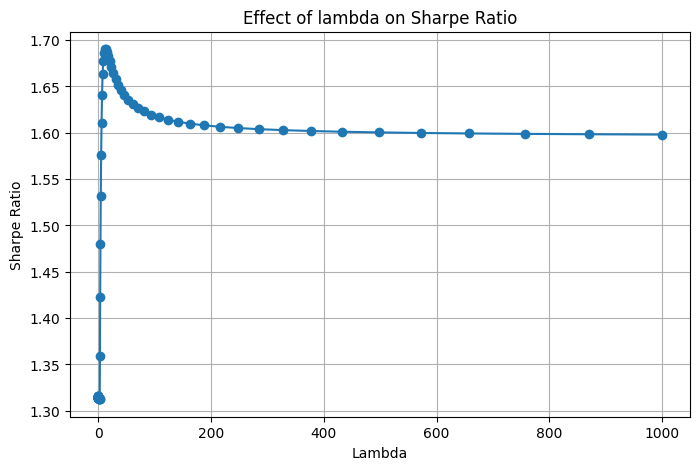

In [19]:
# Plot Sharpe Ratio vs Lambda 
plt.figure(figsize=(8,5))
plt.plot(lambdas, sharpe_ratios, marker='o')
plt.xlabel('Lambda')
plt.ylabel('Sharpe Ratio')
plt.title('Effect of lambda on Sharpe Ratio')
plt.grid(True)
plt.show()

In [20]:
# Find the best lambda 
max_index = np.argmax(sharpe_ratios)

print("Best lambda:", lambdas[max_index])
print("Maximum Sharpe Ratio:", sharpe_ratios[max_index])
print("Optimal weights for best lambda:", opt_weights[max_index])

Best lambda: 11.497569953977356
Maximum Sharpe Ratio: 1.6902306293949072
Optimal weights for best lambda: [0.05881151 0.41427451 0.52672375]
